# Entrega 2 — Baseline U-Net para LoveDA

Este notebook implementa el algoritmo base de segmentación semántica multiclase. Consume el índice generado en la Entrega 1, mantiene Test fuera del experimento y reserva Val oficial para una única evaluación final. No implementa la innovación multiescala.

## 1. Objetivo
Entrenar desde cero una U-Net reproducible con siete clases válidas y medir su rendimiento mediante IoU, Dice/F1 y exactitud de píxel, excluyendo siempre los píxeles no-data.

## 2. Configuración y reproducibilidad
Los hiperparámetros se concentran en `ExperimentConfig`. El dispositivo se selecciona automáticamente y la configuración efectiva queda registrada en `outputs/baseline_unet/config.json` al iniciar el experimento. Por defecto, `RUN_TRAINING=False`: el notebook muestra los artefactos finales existentes sin volver a entrenar ni sobrescribir resultados.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image as DisplayImage
from loveda_baseline import (ExperimentConfig, load_index, resolve_dataset_root,
    runtime_info, seed_everything, make_splits,
    UNet, parameter_counts, smoke_tests, train_experiment)

RUN_TRAINING = False

CONFIG = ExperimentConfig(seed=42, input_size=512, batch_size=4, max_epochs=30,
    learning_rate=1e-3, weight_decay=1e-5, early_stopping_patience=7,
    base_channels=32, use_class_weights=False)
seed_everything(CONFIG.seed)
RUNTIME = runtime_info(CONFIG.seed)
OUTPUT_DIR = Path('outputs/baseline_unet')
display(pd.Series(CONFIG.__dict__, name='valor').to_frame())

python_version: 3.14.8
pytorch_version: 2.14.1+cu132
cuda_available: True
gpu_name: NVIDIA GeForce RTX 4060
seed: 42


,valor
model,U-Net baseline (from scratch)
seed,42
input_size,512
batch_size,4
max_epochs,30
learning_rate,0.001
optimizer,Adam
loss,CrossEntropyLoss(ignore_index=255)
weight_decay,0.00001
early_stopping_patience,7


## 3. Preparación de datos
`outputs/dataset_index.csv` es la fuente principal. Las rutas son relativas a `LOVEDA_ROOT` (o `data/LoveDA`). Antes de entrenar, el pipeline abre todos los pares Train/Val y comprueba existencia, RGB, máscara 2D, dimensiones coincidentes y etiquetas 0..7; cualquier fallo detiene la ejecución.

In [2]:
INDEX = load_index('outputs/dataset_index.csv')
display(INDEX.groupby(['split', 'domain']).size().rename('images').to_frame())
try:
    DATASET_ROOT = resolve_dataset_root()
    print('Dataset localizado:', DATASET_ROOT)
except FileNotFoundError as exc:
    DATASET_ROOT = None
    print(exc)
    print('Configure LOVEDA_ROOT antes de ejecutar la celda de entrenamiento.')

images
split domain        
Test  Rural      976
      Urban      820
Train Rural     1366
      Urban     1156
Val   Rural      992
      Urban      677

Dataset localizado: C:\Users\jbutt\OneDrive\Desktop\proyecto-vpc\data\LoveDA


## 4. División experimental
Train oficial se divide 80/20 mediante una heurística multietiqueta reproducible que combina dominio y presencia de las siete clases. Val oficial permanece separado. Las tablas permiten comprobar dominio y presencia por clase; Test no forma parte de ningún subconjunto.

In [3]:
SPLITS = make_splits(INDEX, seed=CONFIG.seed)
split_summary = pd.read_csv(OUTPUT_DIR/'split_summary.csv')
class_presence = pd.read_csv(OUTPUT_DIR/'class_presence_by_split.csv')
display(split_summary)
display(class_presence.pivot(index=['class_id_original','class_name'], columns='experiment_split', values='percentage_images').round(2))
assert not SPLITS['split'].eq('Test').any()
assert not set(SPLITS.loc[SPLITS.experiment_split.eq('train_internal'),'image_id']) & set(SPLITS.loc[SPLITS.experiment_split.eq('official_val'),'image_id'])

,experiment_split,domain,domain_count,domain_percentage,image_count
0,official_val,Rural,992,59.436788,1669
1,official_val,Urban,677,40.563212,1669
2,train_internal,Rural,1106,54.806739,2018
3,train_internal,Urban,912,45.193261,2018
4,val_internal,Rural,260,51.587302,504
5,val_internal,Urban,244,48.412698,504


,experiment_split,official_val,train_internal,val_internal
class_id_original,class_name,,,
1,background,98.74,97.27,99.21
2,building,65.25,76.46,94.84
3,road,75.43,71.21,90.87
4,water,84.78,59.56,80.75
5,barren,43.20,36.08,73.41
6,forest,71.54,68.88,92.86
7,agriculture,76.75,41.67,69.64


## 5. Preprocesamiento
Las imágenes se redimensionan a 512×512 con interpolación bilinear y se normalizan a [0,1]. Las máscaras usan exclusivamente nearest-neighbor. En entrenamiento se aplican flips horizontal/vertical y rotaciones de 90° sincronizados; validation interno y Val oficial no tienen augmentation.

### Transformación crítica de etiquetas
La máscara oficial usa 0 como ignore y 1..7 como clases. Internamente: `0 → 255`, `1 → 0`, …, `7 → 6`. Por eso la red tiene exactamente siete logits y la pérdida usa `ignore_index=255`. Para visualizar, las predicciones 0..6 vuelven a 1..7.

## 6. U-Net
La arquitectura explícita contiene bloques `DoubleConv`, descenso con max pooling, ascenso con convolución transpuesta y skip connections. Canales: 32–64–128–256–512 y decoder simétrico. Referencia: Ronneberger, Fischer & Brox, *U-Net: Convolutional Networks for Biomedical Image Segmentation*, MICCAI 2015.

In [4]:
MODEL_FOR_INSPECTION = UNet(base=CONFIG.base_channels)
total_parameters, trainable_parameters = parameter_counts(MODEL_FOR_INSPECTION)
print(MODEL_FOR_INSPECTION)
print(f'Parámetros totales: {total_parameters:,}')
print(f'Parámetros entrenables: {trainable_parameters:,}')

UNet(
  (inc): DoubleConv(
    (block): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (block): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (block): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bia

## 7. Función de pérdida y optimización
Baseline principal: `CrossEntropyLoss(ignore_index=255)` sin pesos de clase (`USE_CLASS_WEIGHTS=False`), Adam, learning rate 1e-3 y weight decay 1e-5. El mejor checkpoint se decide solamente por el mayor mIoU de validation interno, con paciencia 7.

## 8. Métricas
Una matriz de confusión acumulada evita retener predicciones completas. De ella se derivan TP, FP, FN, IoU y Dice por clase, promedios macro y pixel accuracy. El target 255 se filtra antes de actualizar la matriz.

In [5]:
# Prueba independiente del dataset: shape, remapeo válido, 7 canales, loss,
# backward, exclusión de ignore, rango de métricas y carga de checkpoint.
import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
smoke_tests(UNet(base=CONFIG.base_channels).to(DEVICE), DEVICE)

Pruebas de humo sintéticas: OK


## 9. Entrenamiento
El experimento final ya fue ejecutado mediante `loveda_baseline.py`. Esta celda solo inicia un nuevo entrenamiento cuando `RUN_TRAINING=True`. El valor predeterminado es `False`, por lo que una ejecución completa del notebook conserva el checkpoint y consume los resultados finales almacenados.

In [6]:
if RUN_TRAINING:
    if DATASET_ROOT is None:
        raise RuntimeError('No se puede entrenar: defina LOVEDA_ROOT y reinicie la ejecución del notebook.')
    RESULT = train_experiment(CONFIG, DATASET_ROOT)
    display(RESULT)
else:
    print('Entrenamiento omitido: se utilizan los resultados finales ya guardados.')

Entrenamiento omitido: se utilizan los resultados finales ya guardados.


## 10. Curvas de entrenamiento
Se muestran directamente las figuras finales ya generadas a partir de las 17 épocas persistidas. Esta sección no regenera curvas ni ejecuta entrenamiento.

,valor
épocas ejecutadas,17.000000
mejor época,10.000000
train loss final,1.016623
validation loss final,1.145623
mejor validation mIoU,0.351053
mejor validation Dice macro,0.484017
Official Val loss,1.395842
Official Val mIoU,0.237645
Official Val Dice macro,0.365227
Official Val pixel accuracy,0.485885


,epoch,train_loss,val_loss,val_miou,val_dice_macro,learning_rate,epoch_time_seconds
0,1,1.482658,1.331818,0.189017,0.285151,0.001,143.830012
1,2,1.345005,1.276402,0.256312,0.380457,0.001,146.629578
2,3,1.294434,1.221590,0.287580,0.409762,0.001,147.158947
3,4,1.261453,1.221154,0.252760,0.372907,0.001,146.126966
4,5,1.221449,1.339930,0.252052,0.384151,0.001,146.360798
5,6,1.192786,1.189814,0.307535,0.438866,0.001,146.369630
6,7,1.172065,1.317133,0.270631,0.394934,0.001,146.255091
7,8,1.142867,1.190835,0.305905,0.428495,0.001,146.309990
8,9,1.126806,1.125366,0.339104,0.472976,0.001,146.181872
9,10,1.098769,1.097999,0.351053,0.484017,0.001,144.755883


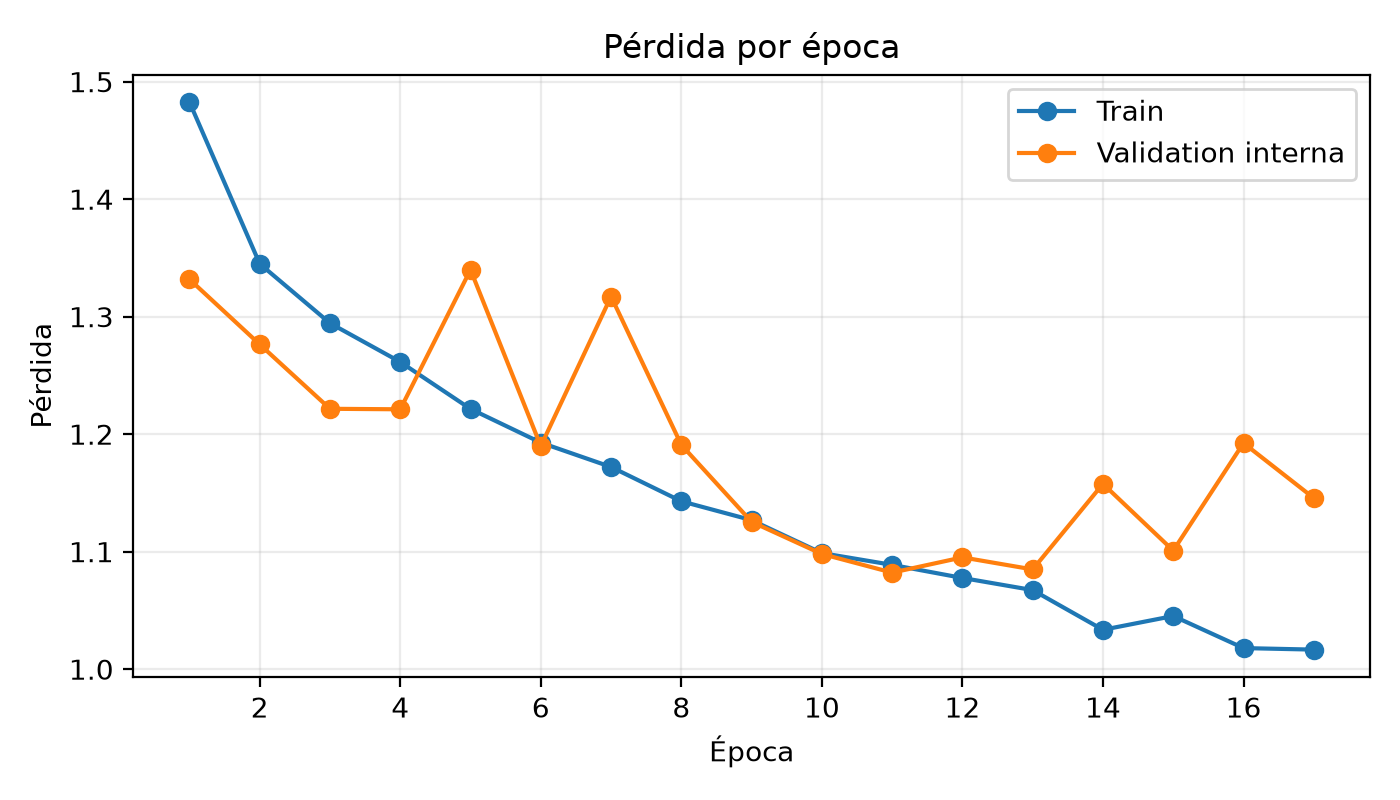

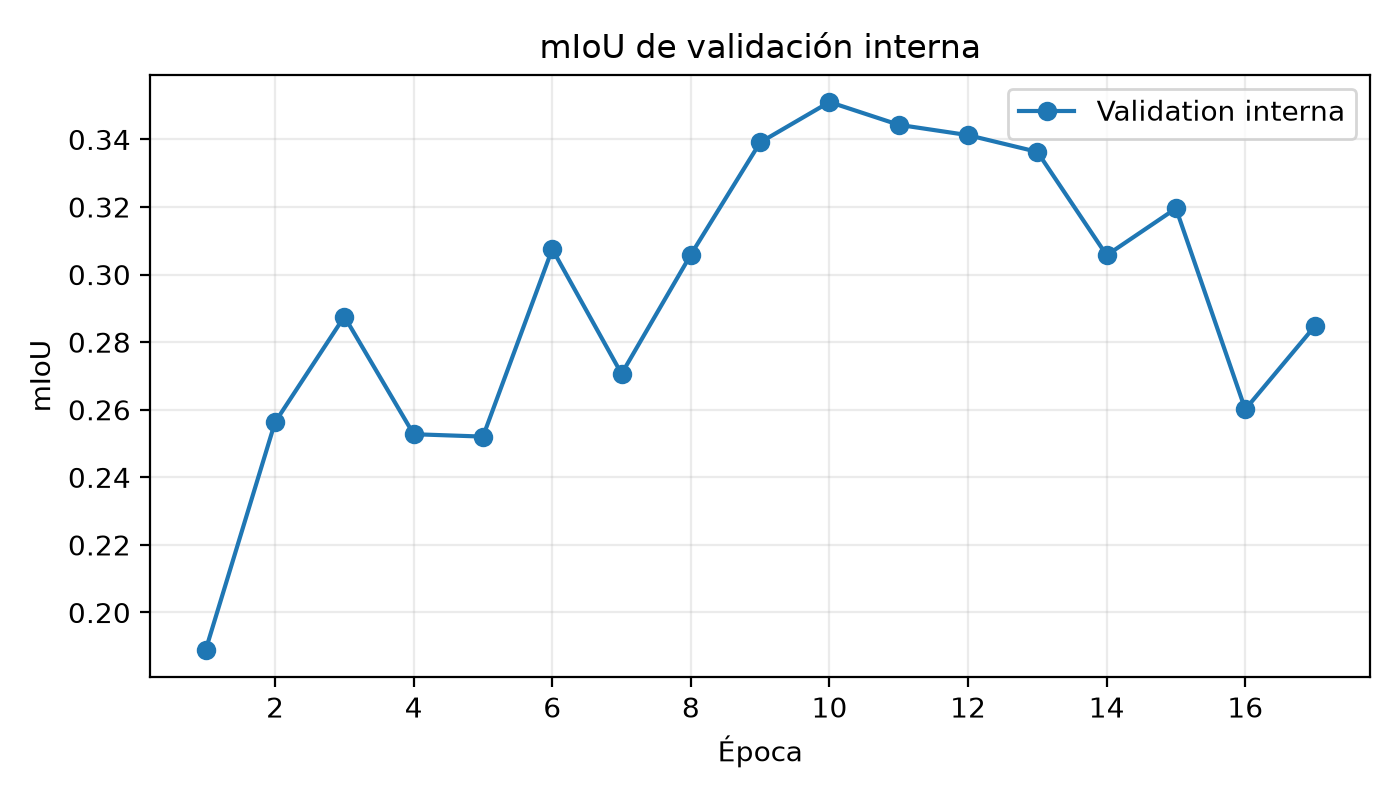

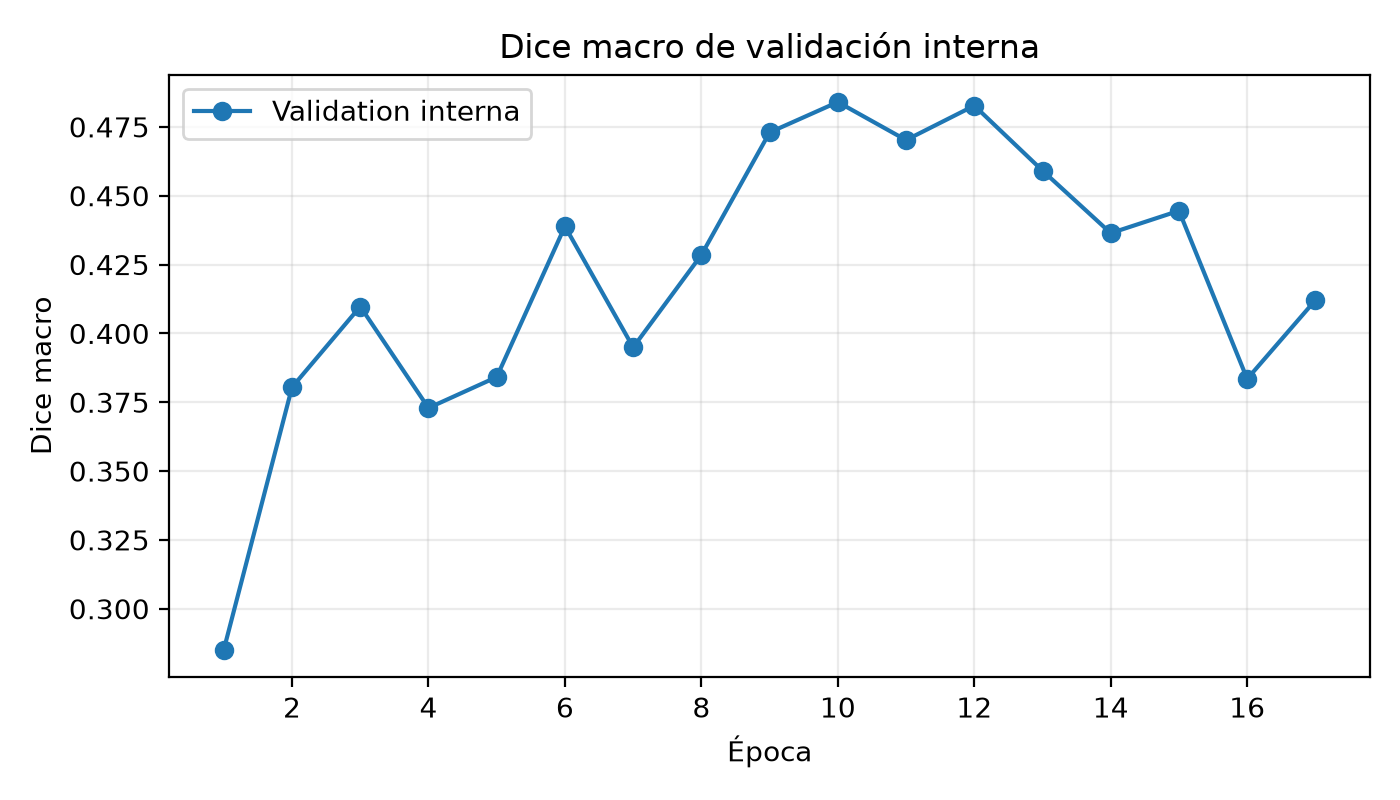

In [7]:
# Carga explícita y de solo lectura de todos los artefactos finales requeridos.
FINAL_CONFIG = json.loads((OUTPUT_DIR/'config.json').read_text(encoding='utf-8'))
HISTORY = pd.read_csv(OUTPUT_DIR/'history.csv')
OFFICIAL_METRICS = json.loads((OUTPUT_DIR/'official_val_metrics.json').read_text(encoding='utf-8'))
PER_CLASS_RESULTS = pd.read_csv(OUTPUT_DIR/'official_val_per_class.csv')
DOMAIN_RESULTS = pd.read_csv(OUTPUT_DIR/'report_domain_results.csv')
CONFUSION_MATRIX = pd.read_csv(OUTPUT_DIR/'confusion_matrix.csv', index_col='ground_truth')
REPORT_SUMMARY = (OUTPUT_DIR/'report_summary.txt').read_text(encoding='utf-8')
RESULT_OBSERVATIONS = (OUTPUT_DIR/'result_observations.txt').read_text(encoding='utf-8')

BEST_ROW = HISTORY.loc[HISTORY['val_miou'].idxmax()]
LAST_ROW = HISTORY.iloc[-1]
training_overview = pd.Series({
    'épocas ejecutadas': len(HISTORY),
    'mejor época': int(BEST_ROW['epoch']),
    'train loss final': LAST_ROW['train_loss'],
    'validation loss final': LAST_ROW['val_loss'],
    'mejor validation mIoU': BEST_ROW['val_miou'],
    'mejor validation Dice macro': HISTORY['val_dice_macro'].max(),
    'Official Val loss': OFFICIAL_METRICS['loss'],
    'Official Val mIoU': OFFICIAL_METRICS['mIoU'],
    'Official Val Dice macro': OFFICIAL_METRICS['Dice_macro'],
    'Official Val pixel accuracy': OFFICIAL_METRICS['pixel_accuracy'],
}, name='valor').to_frame()
display(training_overview)
display(HISTORY)
display(DisplayImage(filename=str(OUTPUT_DIR/'figures/loss_curve.png')))
display(DisplayImage(filename=str(OUTPUT_DIR/'figures/miou_curve.png')))
display(DisplayImage(filename=str(OUTPUT_DIR/'figures/dice_curve.png')))

## 11. Evaluación sobre Val oficial
Esta evaluación usa el checkpoint ya elegido mediante validation interno. Sus resultados no retroalimentan entrenamiento ni selección.

In [8]:
display(pd.Series(OFFICIAL_METRICS, name='valor').to_frame())

,valor
loss,1.395842e+00
mIoU,2.376451e-01
Dice_macro,3.652271e-01
pixel_accuracy,4.858846e-01
image_count,1.669000e+03
valid_pixels,4.260697e+08
ignored_pixels_discarded,1.144863e+07


## 12. Resultados por clase

In [9]:
display(PER_CLASS_RESULTS[['class_name', 'IoU', 'Dice', 'TP', 'FP', 'FN']])

,class_name,IoU,Dice,TP,FP,FN
0,background,0.388015,0.559094,105949469,119243364,47862004
1,building,0.235677,0.381454,14654744,31481884,16044773
2,road,0.106827,0.193033,2558590,4053042,17339070
3,water,0.286568,0.445477,22996992,30355918,26896736
4,barren,0.000594,0.001187,11049,12332,18583703
5,forest,0.318499,0.483123,13924253,12315261,17478870
6,agriculture,0.327335,0.493221,46925607,21587205,74843850


## 13. Urban vs Rural
Este desglose es análisis descriptivo del mismo baseline sobre Val oficial; no constituye adaptación de dominio.

In [10]:
display(DOMAIN_RESULTS.set_index('Domain').loc[['Urban', 'Rural'], ['mIoU', 'Dice_macro']])

,mIoU,Dice_macro
Domain,,
Urban,0.256227,0.387415
Rural,0.219862,0.337366


## 14. Matriz de confusión

,background,building,road,water,barren,forest,agriculture
ground_truth,,,,,,,
background,105949469,24778310,2208520,9410427,3433,6143724,5317590
building,14983583,14654744,565729,113290,0,211808,170363
road,14537955,2058241,2558590,130737,153,314397,297587
water,18027356,736512,199197,22996992,559,809707,7123405
barren,12335634,127588,156072,156044,11049,68079,5740286
forest,13208198,1154577,24055,153960,106,13924253,2937974
agriculture,46150638,2626656,899469,20391460,8081,4767546,46925607


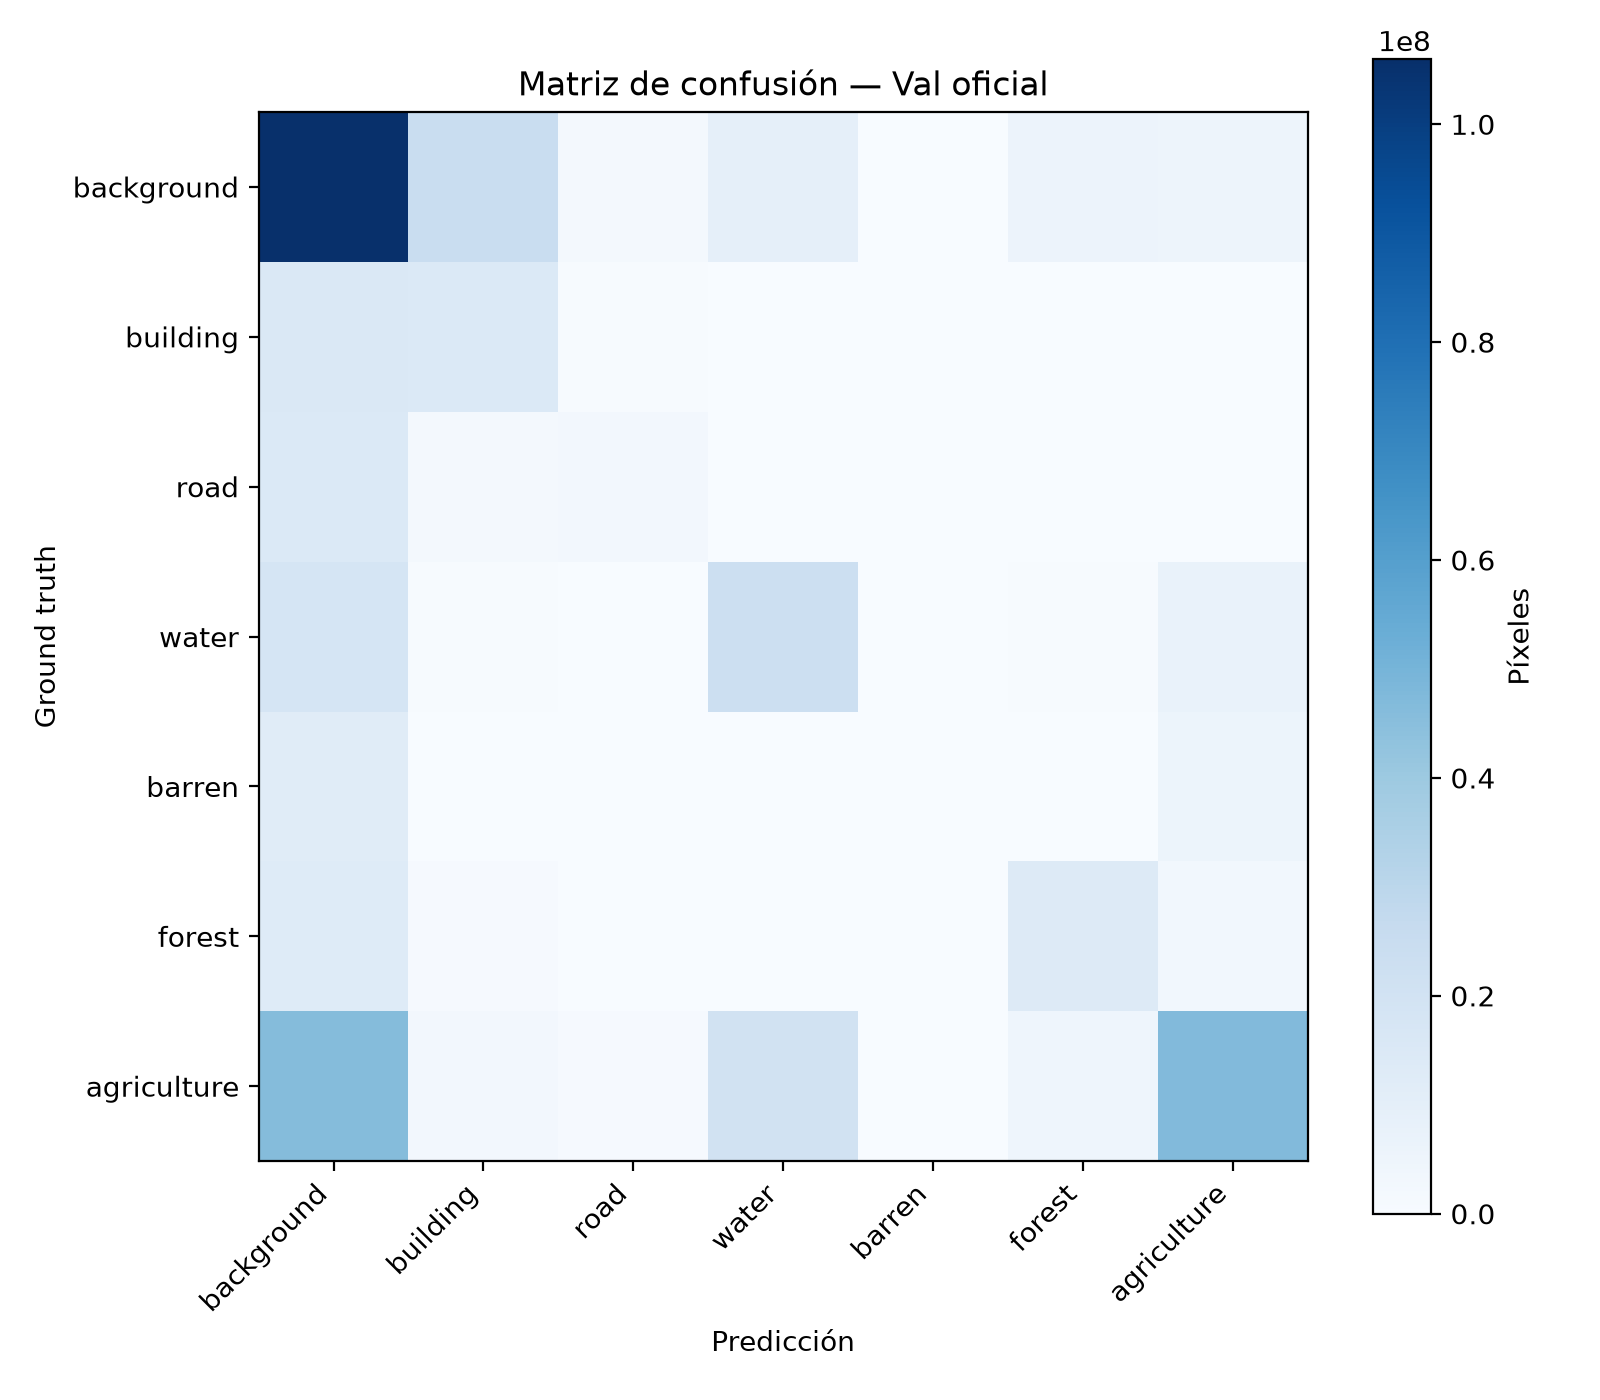

In [11]:
display(CONFUSION_MATRIX)
display(DisplayImage(filename=str(OUTPUT_DIR/'figures/confusion_matrix.png')))

## 15. Resultados cualitativos
La selección usa seed 42 e incluye cuatro muestras Urban y cuatro Rural sin inspeccionar previamente su rendimiento.

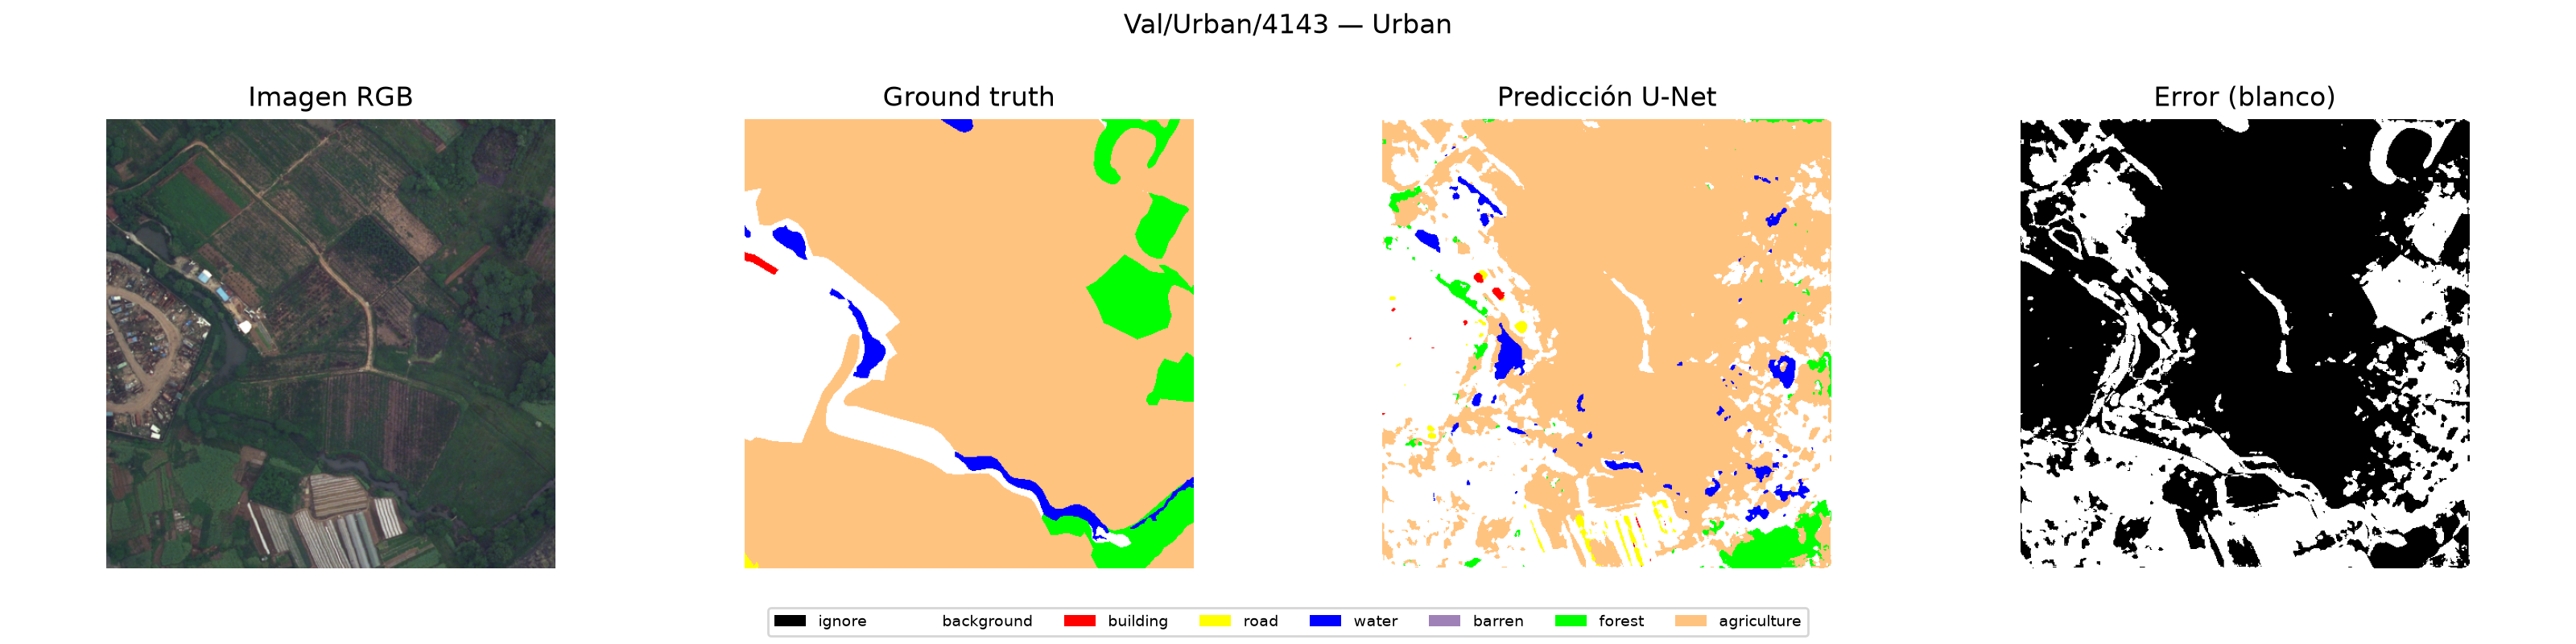

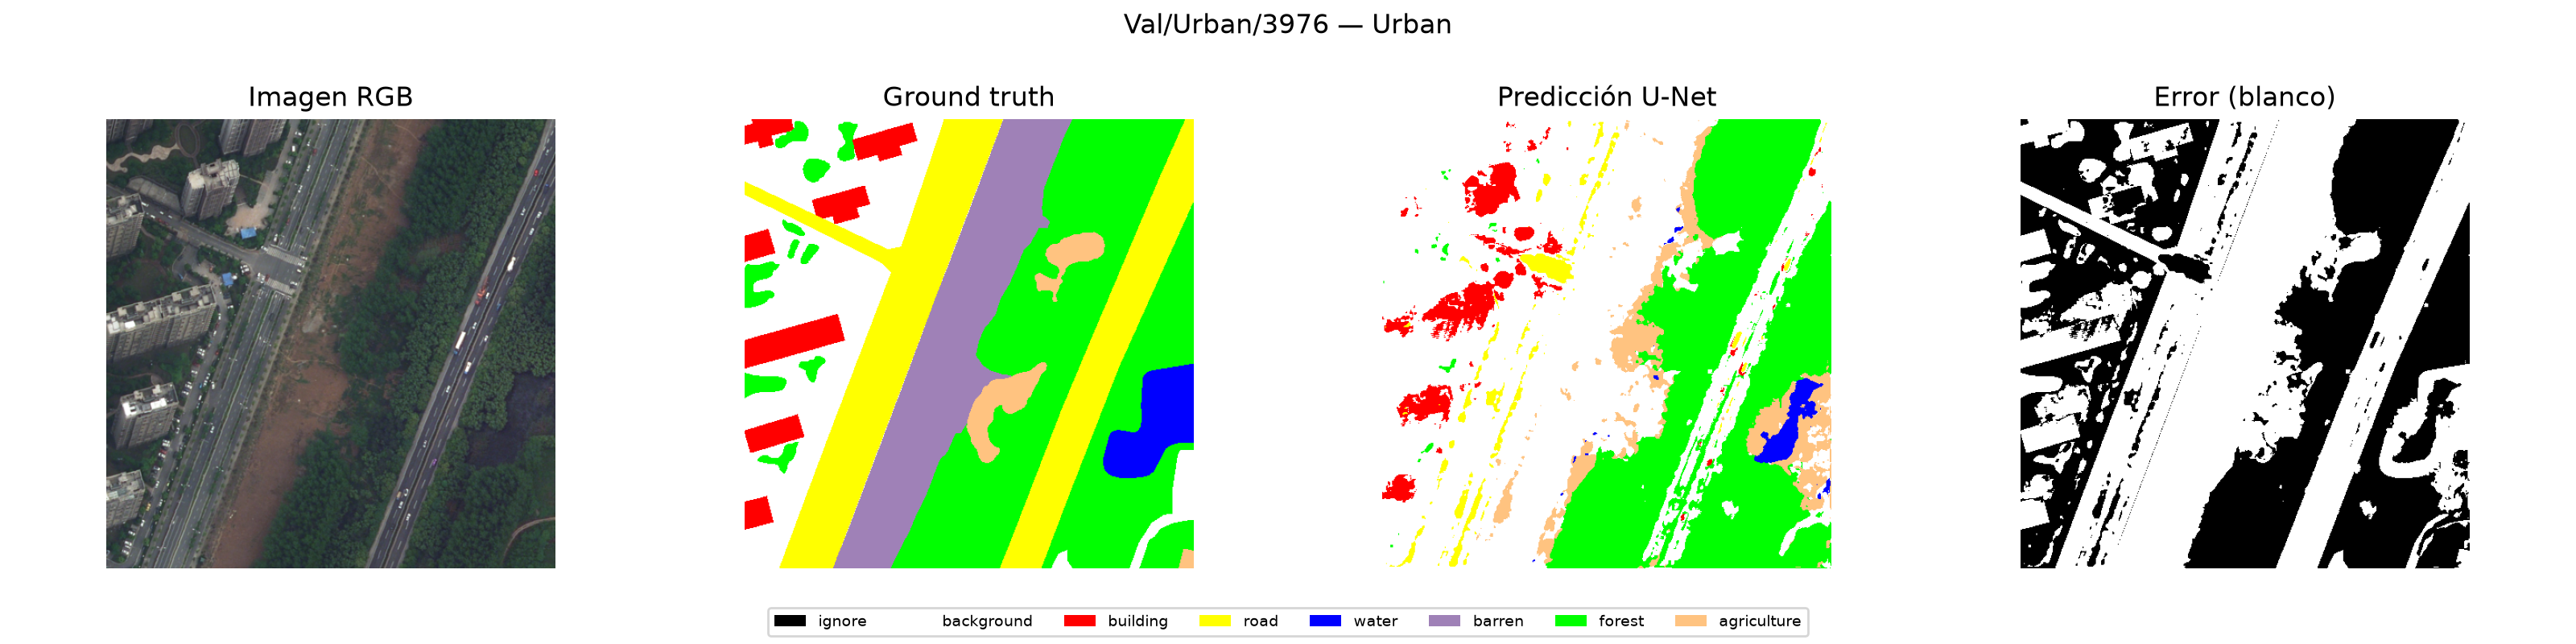

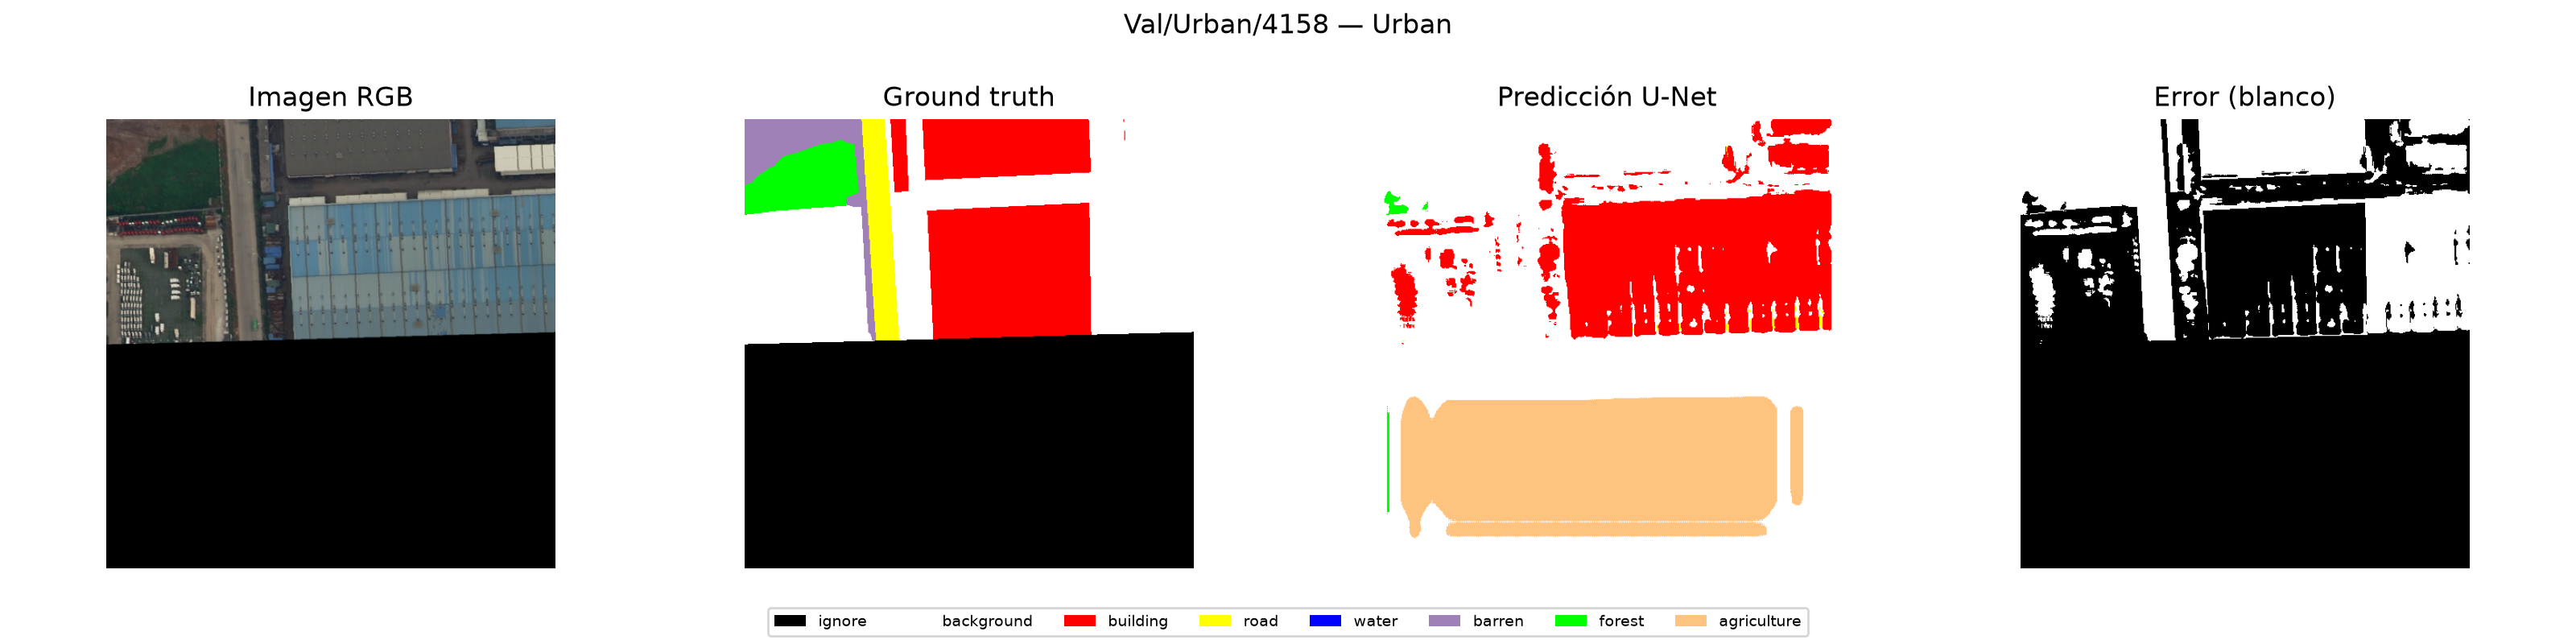

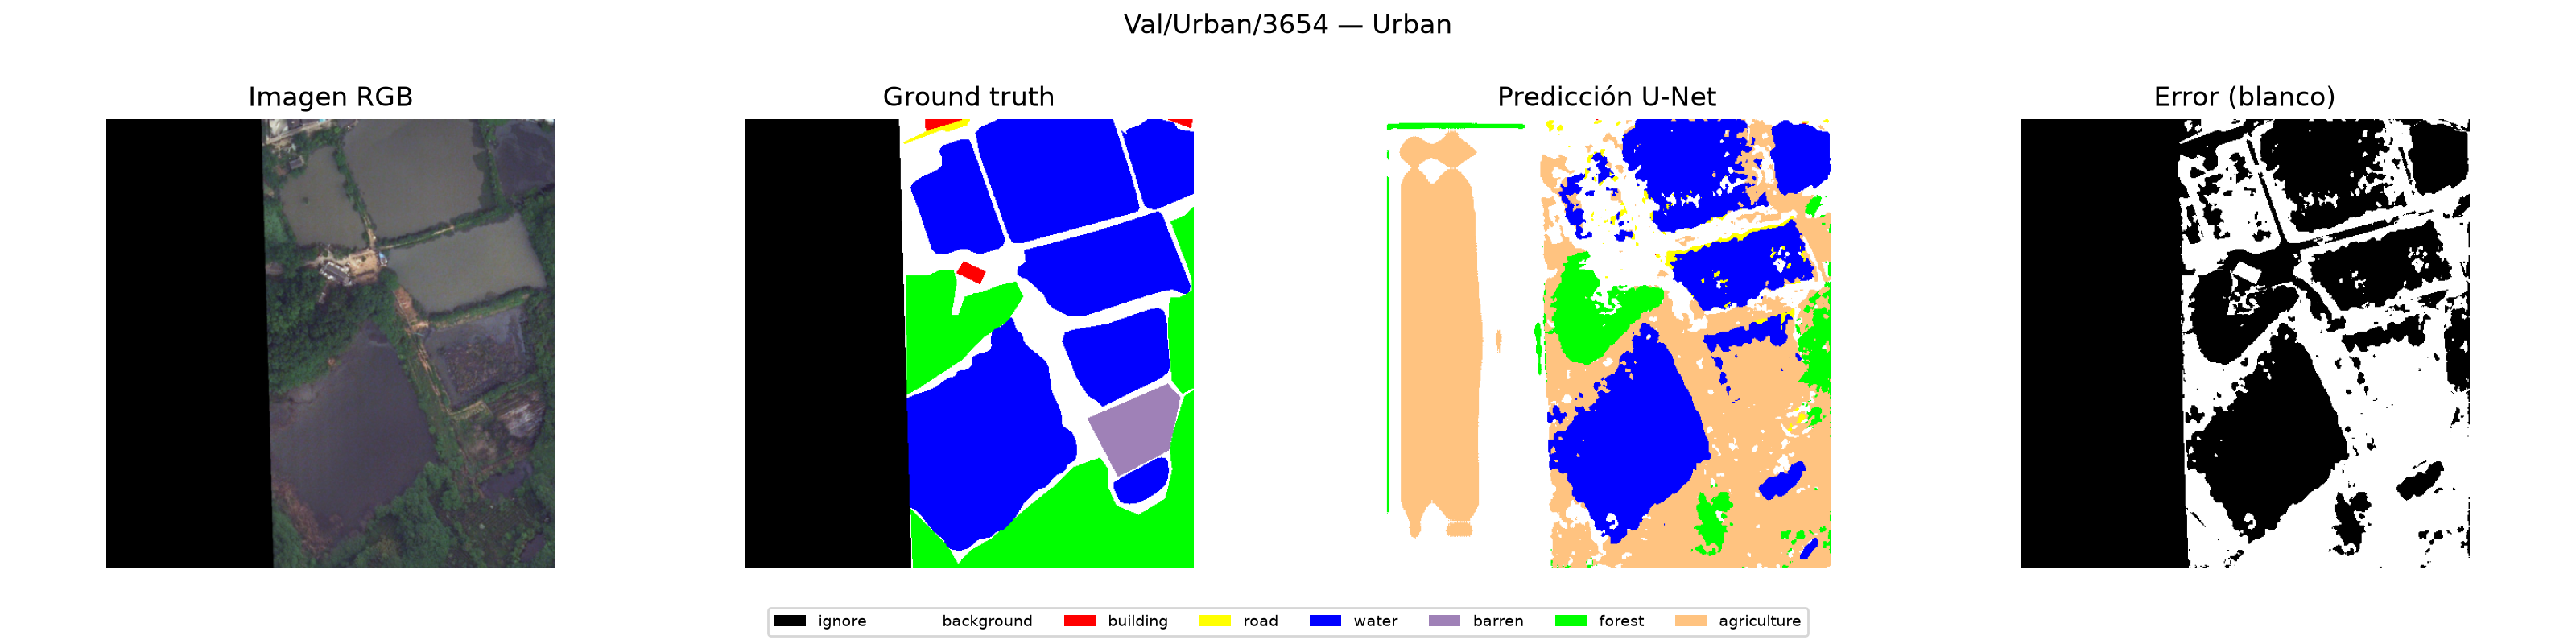

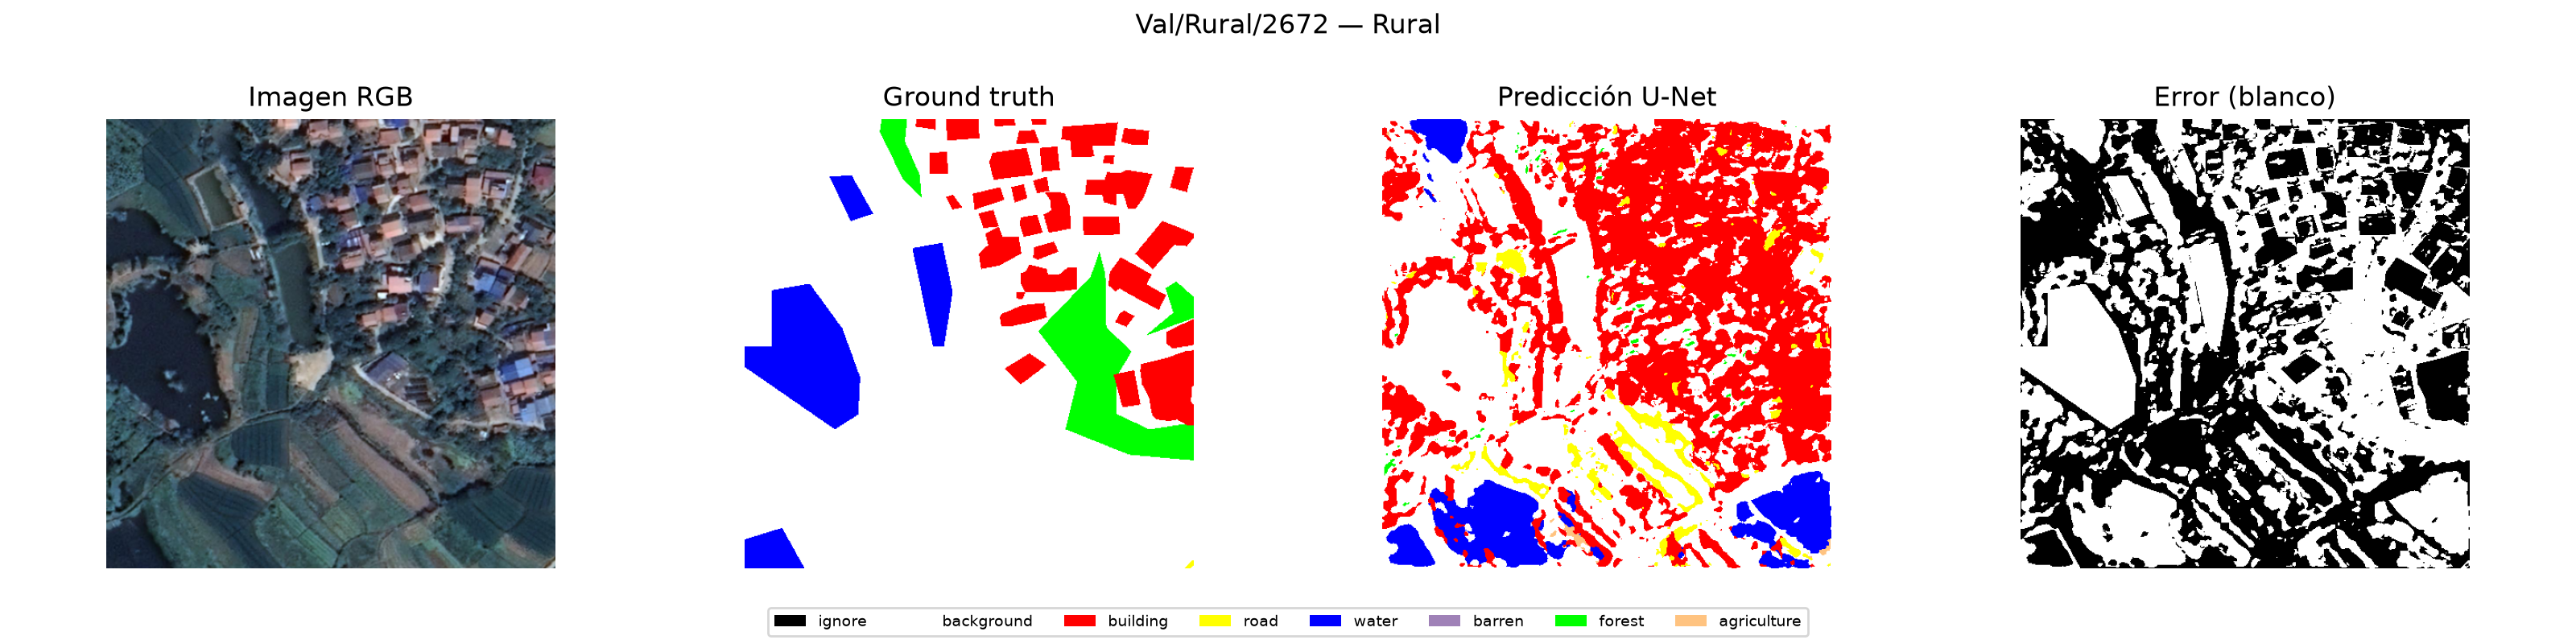

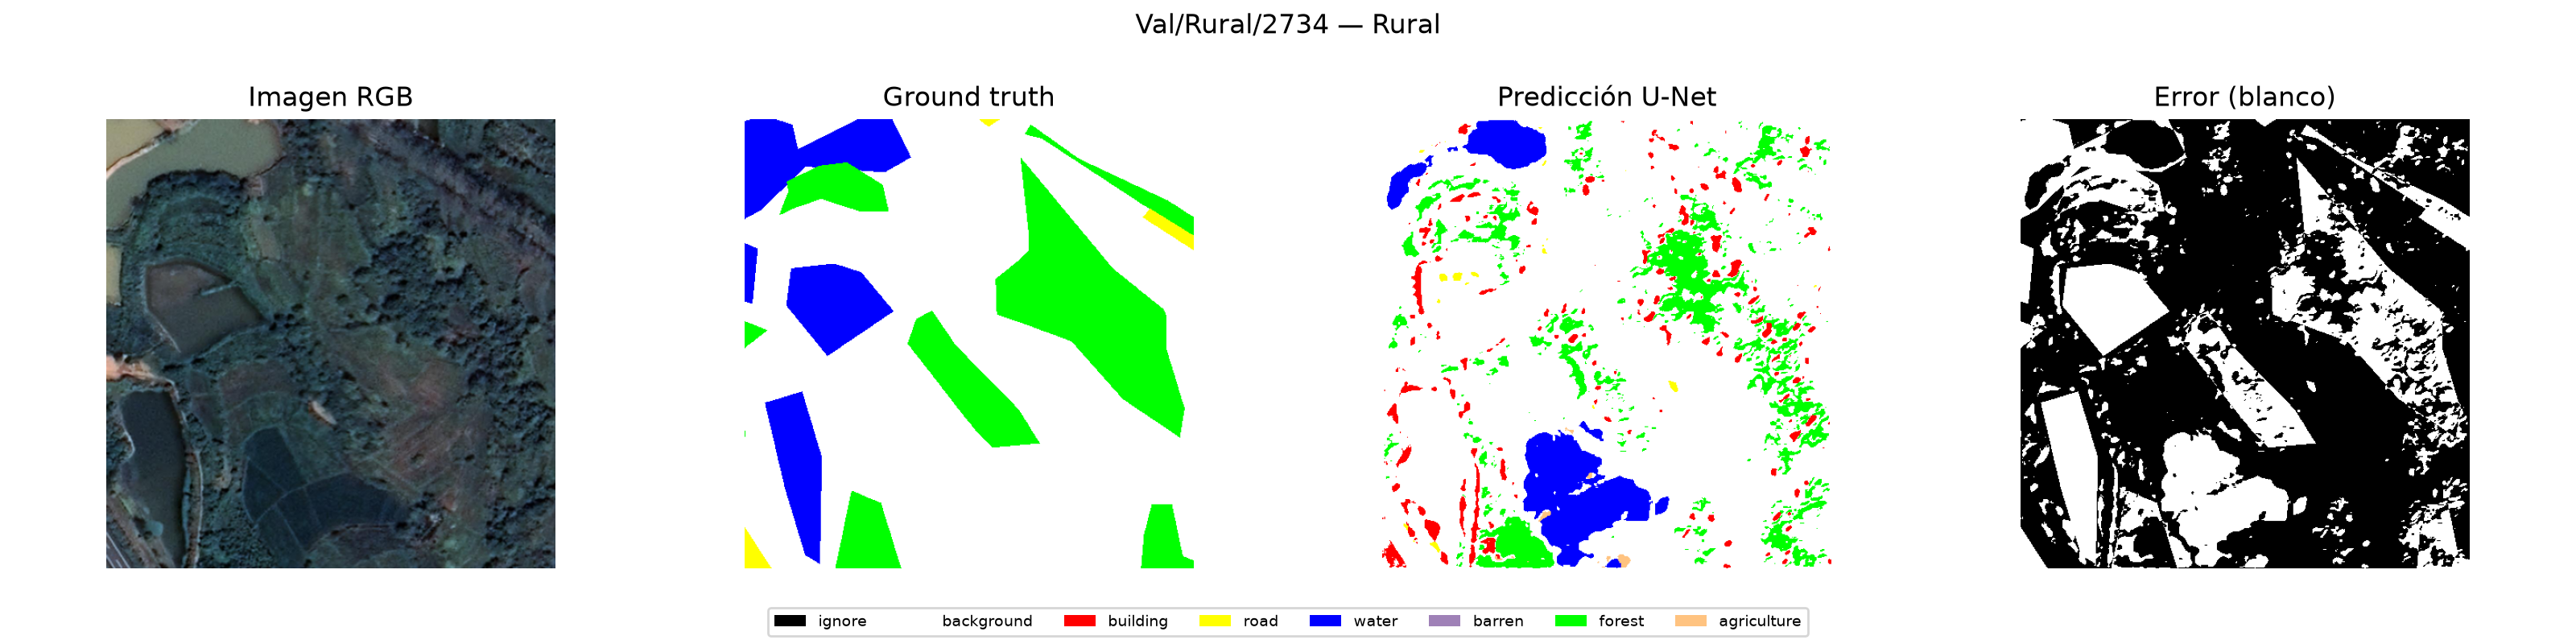

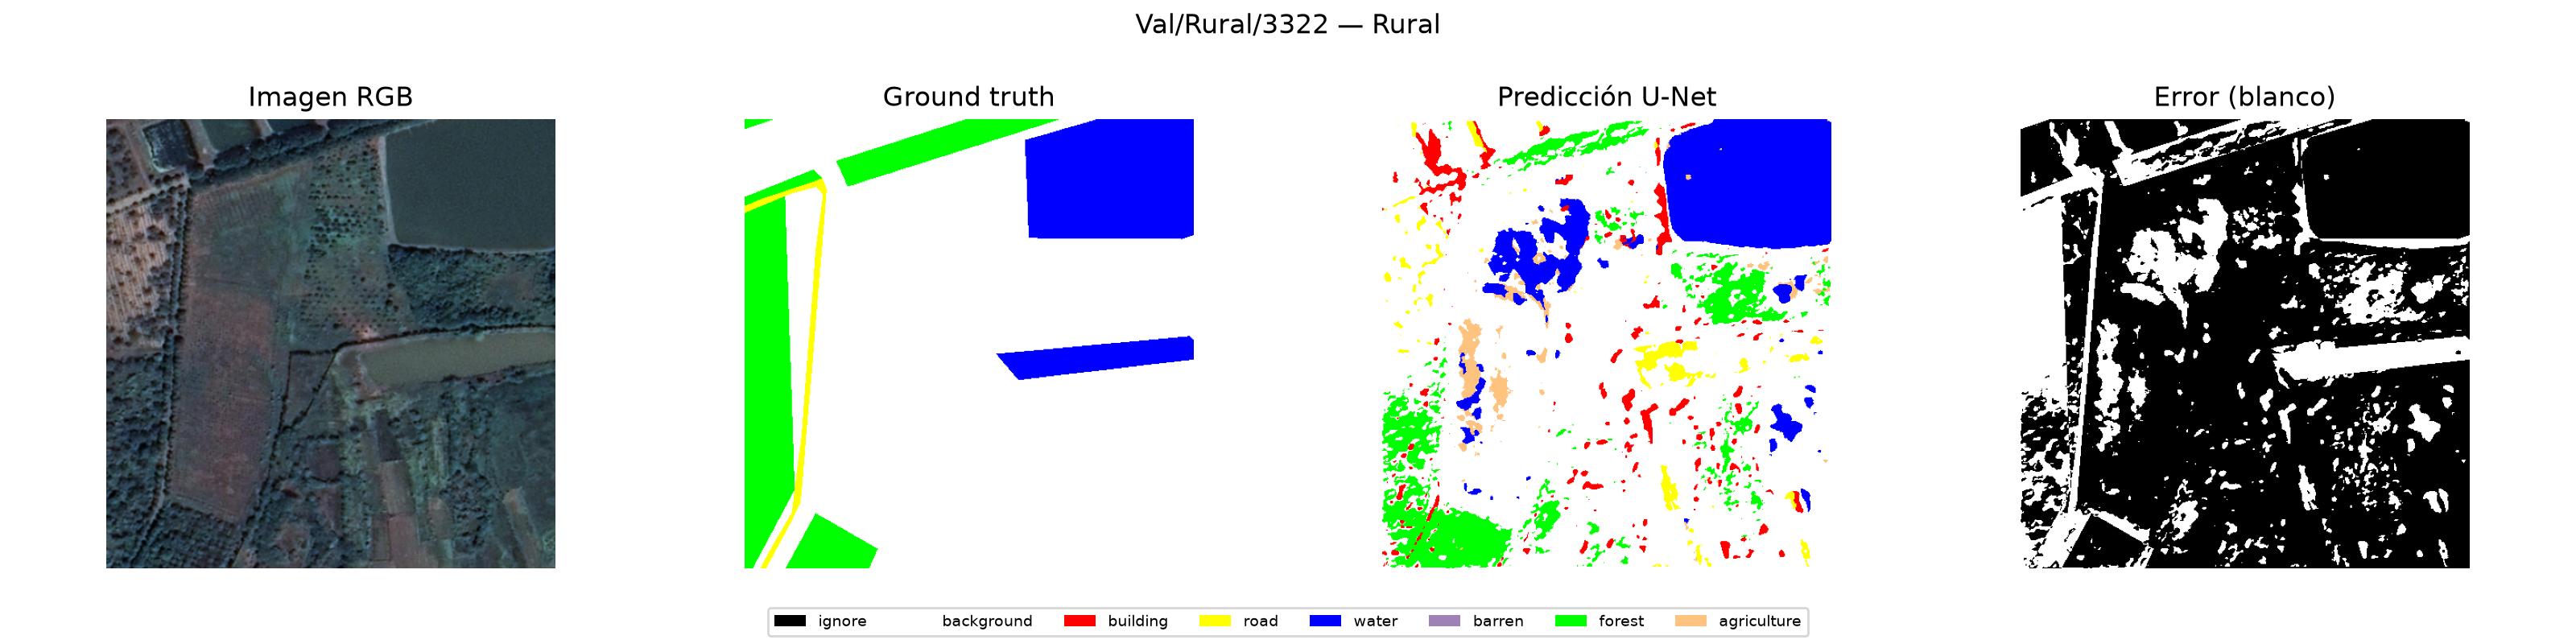

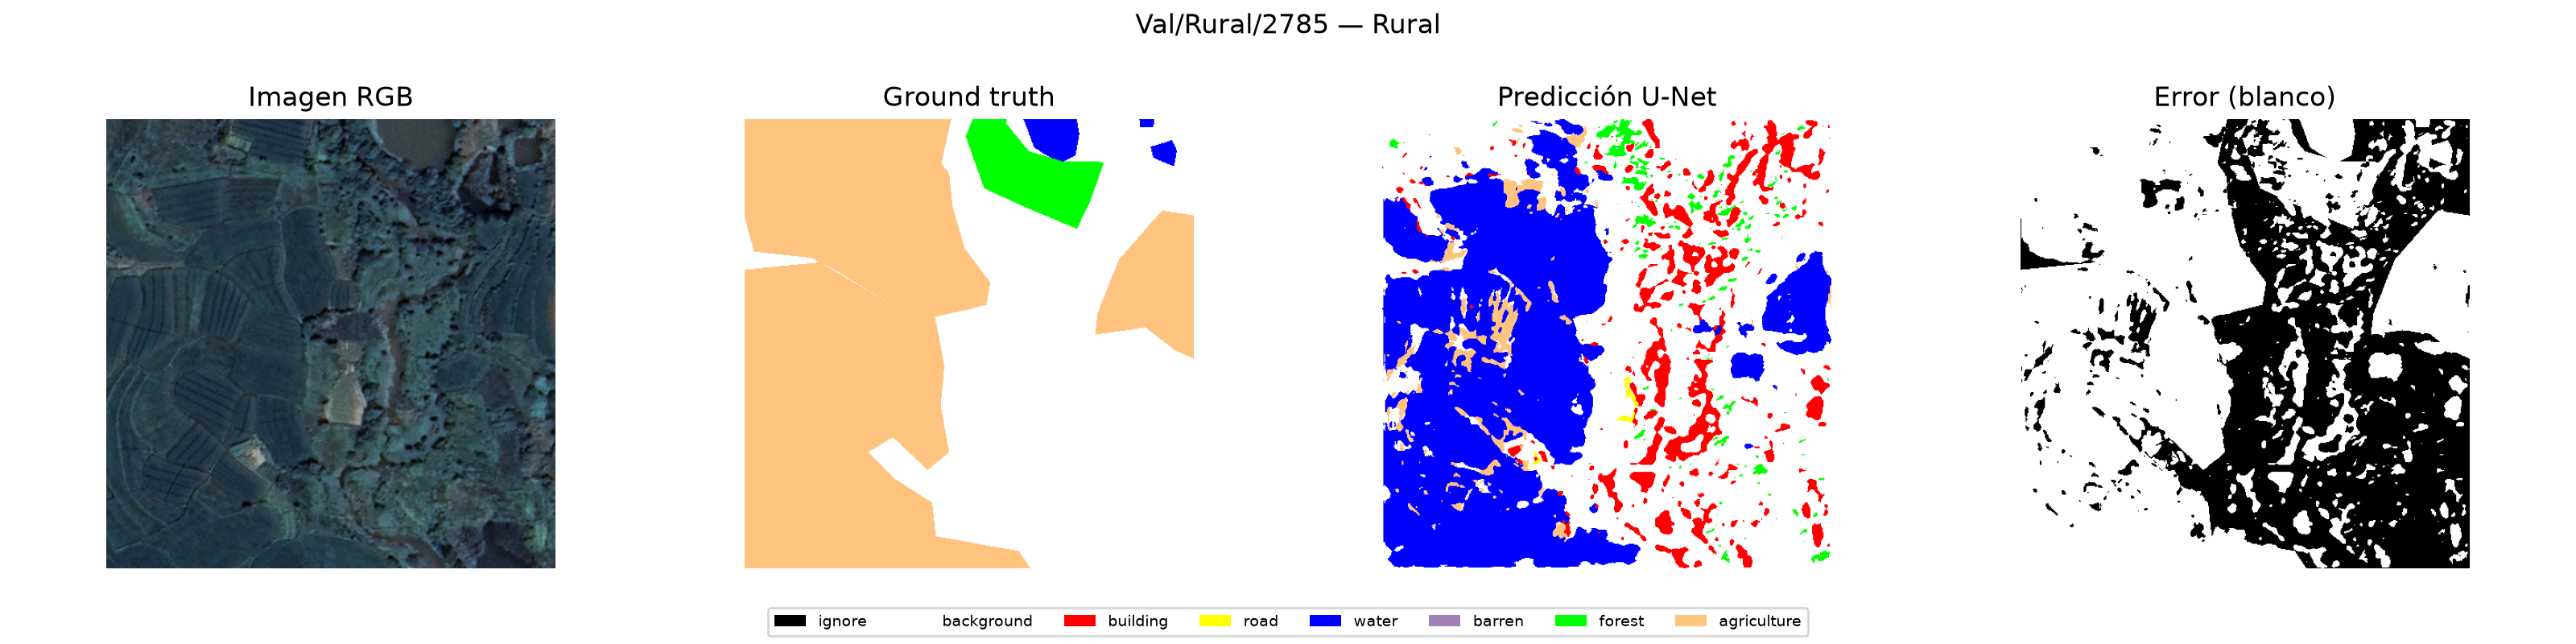

In [12]:
for path in sorted((OUTPUT_DIR/'figures/qualitative').glob('sample_*.png')):
    display(DisplayImage(filename=str(path)))

## 16. Resumen para el informe
El texto siguiente se calcula únicamente desde la ejecución real y se guarda idéntico en `report_summary.txt`.

In [13]:
print(REPORT_SUMMARY)
display(pd.read_csv(OUTPUT_DIR/'report_main_results.csv'))
display(pd.read_csv(OUTPUT_DIR/'report_per_class_results.csv'))
display(pd.read_csv(OUTPUT_DIR/'report_domain_results.csv'))

RESUMEN REAL — BASELINE U-NET
Dataset: LoveDA
Modelo: U-Net baseline (from scratch)
Resolución utilizada: 512x512
Train interno: 2018 imágenes
Validation interno: 504 imágenes
Official Val: 1669 imágenes
Mejor epoch: 10
Loss official Val: 1.395842
mIoU official Val: 0.237645
Dice macro official Val: 0.365227
Pixel accuracy: 0.485885
mIoU Urban: 0.256227
mIoU Rural: 0.219862
Número de parámetros: 7763239
Tiempo total de entrenamiento: 2446.11 s
IoU y Dice por clase:
- background: IoU=0.388015, Dice=0.559094
- building: IoU=0.235677, Dice=0.381454
- road: IoU=0.106827, Dice=0.193033
- water: IoU=0.286568, Dice=0.445477
- barren: IoU=0.000594, Dice=0.001187
- forest: IoU=0.318499, Dice=0.483123
- agriculture: IoU=0.327335, Dice=0.493221



,method,mIoU,Dice_macro,pixel_accuracy,official_val_loss,best_epoch,trainable_parameters,input_size
0,U-Net baseline,0.237645,0.365227,0.485885,1.395842,10,7763239,512


,Clase,IoU,Dice
0,background,0.388015,0.559094
1,building,0.235677,0.381454
2,road,0.106827,0.193033
3,water,0.286568,0.445477
4,barren,0.000594,0.001187
5,forest,0.318499,0.483123
6,agriculture,0.327335,0.493221


,Domain,mIoU,Dice_macro
0,Rural,0.219862,0.337366
1,Urban,0.256227,0.387415


## 17. Conclusiones experimentales automáticas
Las observaciones cuantifican generalización, extremos por clase, diferencia de dominio y confusiones principales; no asignan juicios subjetivos al modelo.

In [14]:
print(RESULT_OBSERVATIONS)

El mejor checkpoint correspondió a la época 10 según mIoU de validación interna (0.351053).
En esa época, la diferencia val_loss - train_loss fue -0.000770.
Después del mejor epoch se observaron 4 descensos inter-época de mIoU de validación.
La clase background obtuvo el mayor IoU (0.388015), mientras que barren obtuvo el menor (0.000594).
La diferencia absoluta de mIoU entre Urban y Rural fue 0.036364.
Mayores confusiones dirigidas: agriculture → background (46,150,638 píxeles); background → building (24,778,310 píxeles); agriculture → water (20,391,460 píxeles).



### Nota de reproducibilidad y protección de resultados

El experimento final fue ejecutado previamente mediante `loveda_baseline.py` utilizando GPU CUDA. Para evitar sobrescribir el checkpoint y los resultados finales, este notebook está configurado con `RUN_TRAINING=False` y carga los artefactos finales almacenados en `outputs/baseline_unet/`. El entrenamiento puede reproducirse estableciendo `RUN_TRAINING=True`.